## (옵션) Neo4j 설치

### 설치 

1. docker-compose.yml 파일이 있는 폴더로 이동 
2. `docker-compose up -d` 명령어 실행  

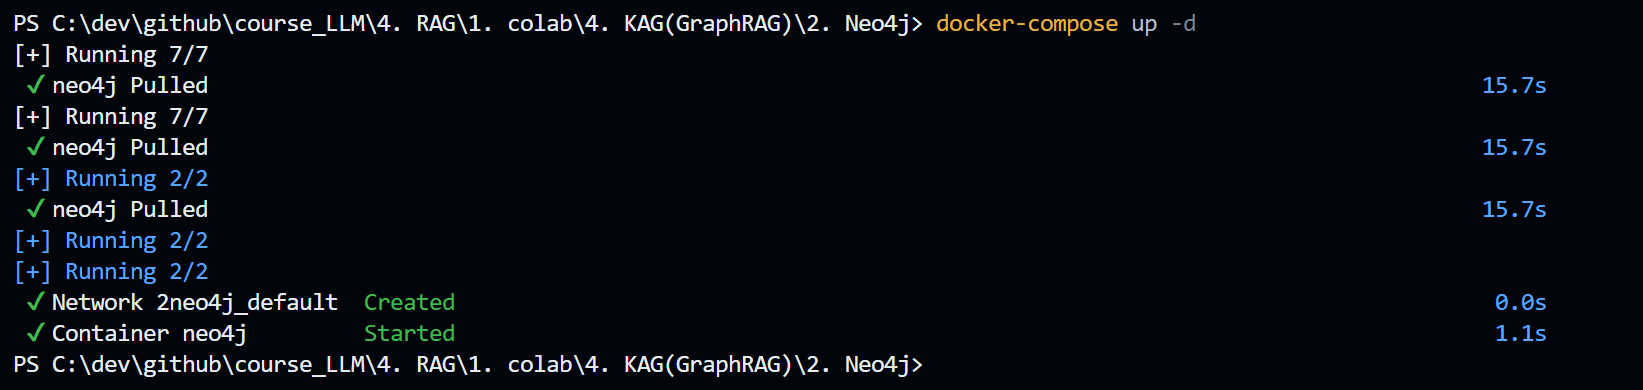

### WEB UI 접속 

1. `http://localhost:7474` 접속 
2. 아이디 / 비번 : `neo4j/test1234`

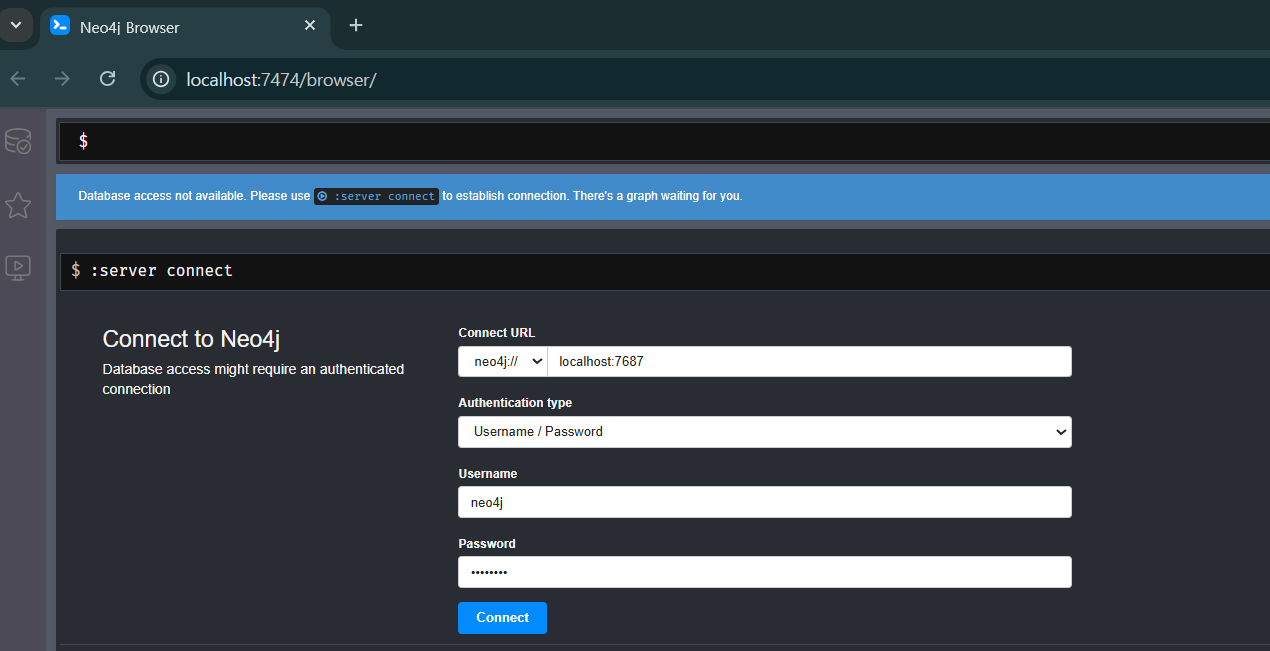

> 로그인 성공 화면 

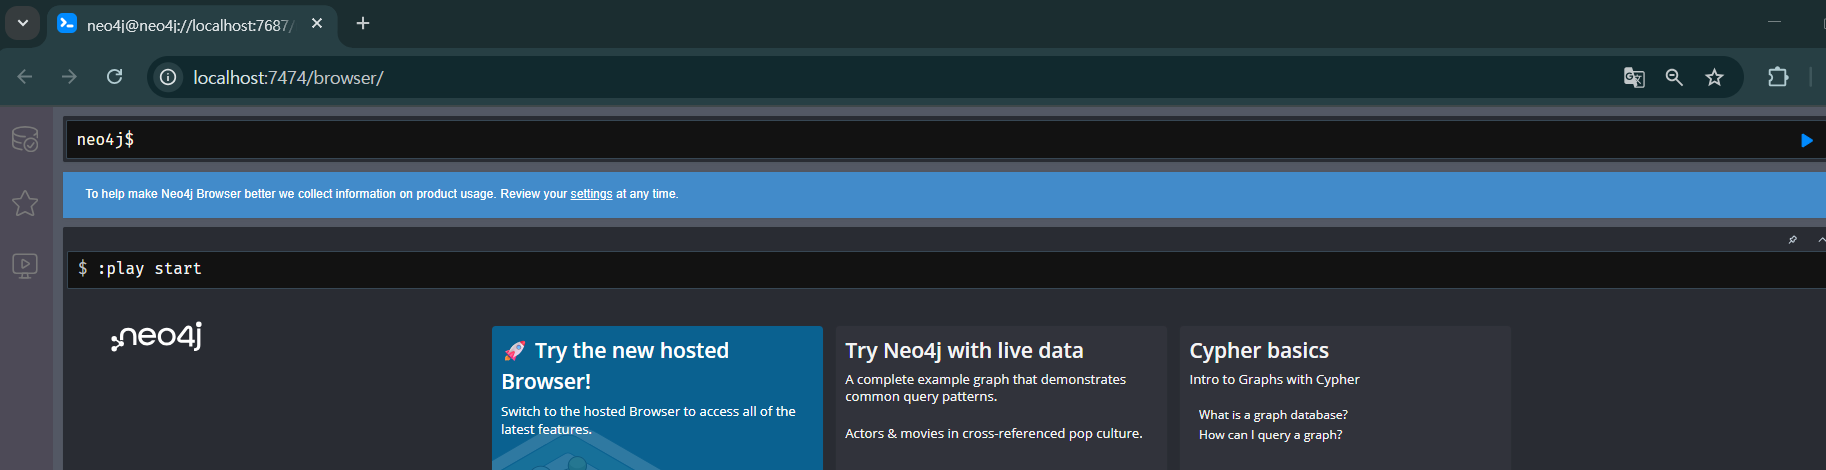

## 1. Cypher란?

**Cypher**는 Neo4j 그래프 데이터베이스를 위한 선언적(declarative) 쿼리 언어입니다.

### 특징
- **직관적인 문법**: 사람이 읽고 쓰기 쉬운 문법
- **그래프 중심**: 노드와 관계를 자연스럽게 표현
- **SQL과 유사**: SQL을 알고 있다면 쉽게 배울 수 있음

### SQL vs Cypher 비교

| SQL | Cypher |
|-----|--------|
| `SELECT * FROM users` | `MATCH (u:User) RETURN u` |
| `JOIN` 명시적 필요 | 관계 패턴으로 자동 연결 |
| 테이블 기반 | 그래프 기반 |


## 2. 기본 개념

### 2.1 노드 (Node)
- 그래프의 기본 단위
- 개체를 나타냄 (사람, 회사, 제품 등)
- **레이블(Label)**: 노드의 분류 (`:Person`, `:Company`)
- **속성(Property)**: 키-값 쌍의 데이터 (`{name: "홍길동", age: 30}`)

**문법**: `(변수명:레이블 {속성})`

### 2.2 관계 (Relationship)
- 두 노드 간의 연결
- 방향성을 가짐 (→ 또는 ←)
- **타입(Type)**: 관계의 종류 (`[:KNOWS]`, `[:WORKS_AT]`)
- 속성을 가질 수 있음

**문법**: `(노드1)-[:관계타입 {속성}]->(노드2)`

### 2.3 주요 키워드

| 키워드 | 기능 | 예시 |
|--------|------|------|
| `CREATE` | 노드/관계 생성 | `CREATE (p:Person {name: "홍길동"})` |
| `MATCH` | 패턴 찾기 | `MATCH (p:Person) RETURN p` |
| `RETURN` | 결과 반환 | `RETURN p.name, p.age` |
| `WHERE` | 조건 필터링 | `WHERE p.age > 25` |
| `MERGE` | 있으면 유지, 없으면 생성 | `MERGE (p:Person {name: "홍길동"})` |
| `SET` | 속성 추가/수정 | `SET p.age = 31` |
| `DELETE` | 삭제 | `DELETE p` |
| `DETACH DELETE` | 관계 포함 삭제 | `DETACH DELETE p` |


## 3. 노드 생성과 조회

### 3.1 노드 생성 (CREATE)

가장 기본적인 노드 생성 방법입니다.


#### Neo4j 드라이버 생성

In [2]:
# Neo4j Python 드라이버를 import합니다.
# GraphDatabase: Neo4j 데이터베이스와 통신하기 위한 드라이버 클래스
from neo4j import GraphDatabase

# ============================================
# Neo4j 연결 정보 설정
# ============================================
# URI: Neo4j 데이터베이스의 주소
#   - bolt:// : Neo4j의 네이티브 프로토콜 (포트 7687)
#   - localhost:7687 : 로컬 컴퓨터의 Neo4j 서버
URI = "bolt://localhost:7687"

# USERNAME: Neo4j 데이터베이스 사용자명 (기본값: neo4j)
USERNAME = "neo4j"

# PASSWORD: Neo4j 데이터베이스 비밀번호
# 주의: 실제 환경에서는 환경변수나 설정 파일에서 읽어오는 것이 안전합니다.
PASSWORD = "test1234"  # 실제 비밀번호로 변경하세요.

# ============================================
# Neo4j 드라이버 생성
# ============================================
# driver: Neo4j 데이터베이스와의 연결을 관리하는 드라이버 객체
# GraphDatabase.driver(): URI와 인증 정보를 사용하여 드라이버 생성
driver = GraphDatabase.driver(URI, auth=(USERNAME, PASSWORD))

#### Cypher 쿼리 실행 헬퍼 함수

In [3]:
# ============================================
# Cypher 쿼리 실행 헬퍼 함수
# ============================================
def run_query(query, parameters=None):
    """
    Cypher 쿼리를 실행하는 헬퍼 함수
    
    Args:
        query (str): 실행할 Cypher 쿼리 문자열
        parameters (dict, optional): 쿼리에 전달할 파라미터 딕셔너리
    
    Returns:
        list: 쿼리 결과 레코드들의 리스트
    
    사용 예시:
        result = run_query("MATCH (p:Person) RETURN p.name")
    """
    # driver.session(): 데이터베이스 세션 생성
    # 세션은 쿼리를 실행하는 컨텍스트를 제공합니다.
    with driver.session() as session:
        # session.run(): Cypher 쿼리를 실행
        # parameters or {}: 파라미터가 없으면 빈 딕셔너리 사용
        result = session.run(query, parameters or {})
        
        # 결과를 리스트로 변환하여 반환
        # record: 쿼리 결과의 각 행을 나타내는 객체
        return [record for record in result]


#### 연결 테스트

In [4]:
# ============================================
# 연결 테스트
# ============================================
# Neo4j 연결이 정상적으로 작동하는지 확인합니다.
try:
    # 간단한 테스트 쿼리 실행
    # "RETURN 1 as test": 숫자 1을 반환하는 간단한 쿼리
    result = run_query("RETURN 1 as test")
    print("Neo4j 연결 성공!")
except Exception as e:
    # 연결 실패 시 에러 메시지 출력
    print(f"Neo4j 연결 실패: {e}")


Neo4j 연결 성공!


### 예제 1: 단일 노드 생성

Person 레이블을 가진 노드를 생성합니다.


In [5]:
# ============================================
# Cypher 쿼리 작성
# ============================================
# CREATE: 새로운 노드나 관계를 생성하는 키워드
# (:Person {...}): Person 레이블을 가진 노드 생성
#   - :Person: 노드의 레이블 (분류)
#   - {...}: 노드의 속성 (키-값 쌍)
#     - name: '홍길동': 이름 속성
#     - job: 'AI강사': 직업 속성
#     - age: 30: 나이 속성
query = """
CREATE (:Person {name: '홍길동', job: 'AI강사', age: 30})
"""

# ============================================
# 쿼리 실행
# ============================================
# run_query() 함수를 사용하여 쿼리 실행
# 이 쿼리는 노드를 생성만 하고 결과를 반환하지 않으므로 result는 빈 리스트일 수 있습니다.
result = run_query(query)

# ============================================
# 결과 확인
# ============================================
print("노드가 생성되었습니다!")
print("팁: Neo4j Browser에서 'MATCH (p:Person) RETURN p' 쿼리로 생성된 노드를 확인할 수 있습니다.")


노드가 생성되었습니다!
팁: Neo4j Browser에서 'MATCH (p:Person) RETURN p' 쿼리로 생성된 노드를 확인할 수 있습니다.


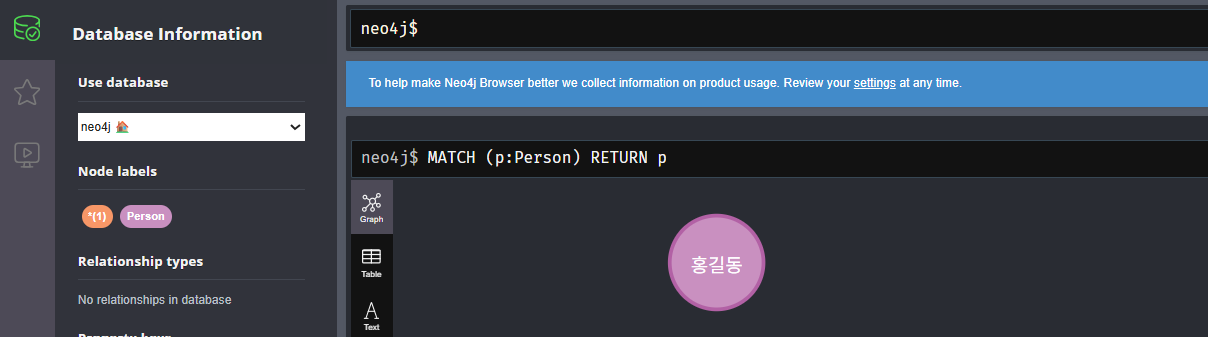

### 예제 2: 여러 노드 생성

한 번에 여러 노드를 생성할 수 있습니다.


In [6]:
# ============================================
# Cypher 쿼리 작성
# ============================================
# CREATE 키워드 뒤에 여러 노드를 쉼표로 구분하여 나열
# 각 노드는 독립적으로 생성됩니다.
query = """
CREATE 
    (:Person {name: '신사임당', job: '웹개발강사', age: 28}),
    (:Person {name: '이순신', job: '데이터엔지니어', age: 35}),
    (:Person {name: '세종대왕', job: '프로젝트매니저', age: 40})
"""

# ============================================
# 쿼리 실행
# ============================================
result = run_query(query)

# ============================================
# 결과 확인
# ============================================
print("여러 노드가 생성되었습니다!")
print("팁: 한 번에 여러 노드를 생성하면 네트워크 왕복 횟수가 줄어 성능이 향상됩니다.")


여러 노드가 생성되었습니다!
팁: 한 번에 여러 노드를 생성하면 네트워크 왕복 횟수가 줄어 성능이 향상됩니다.


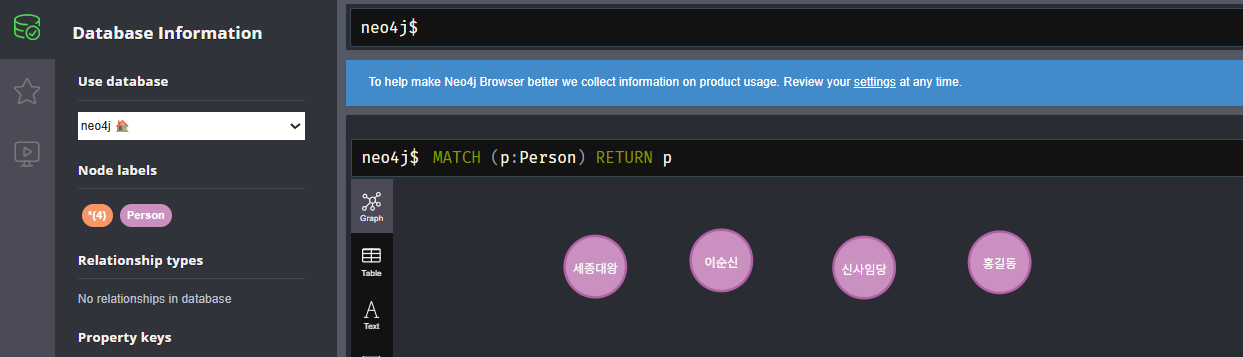

### 예제 3: 모든 노드 조회 (MATCH)

생성한 노드들을 조회해봅시다.


In [7]:
# ============================================
# Cypher 쿼리 작성
# ============================================
# MATCH: 데이터베이스에서 패턴과 일치하는 노드나 관계를 찾는 키워드
#   - (p:Person): Person 레이블을 가진 노드를 찾고, 변수 p에 할당
#     - p: 변수명 (나중에 참조할 수 있음)
#     - :Person: 노드의 레이블
# RETURN: 쿼리 결과로 반환할 데이터 지정
#   - p.name as 이름: 노드의 name 속성을 '이름'이라는 별칭으로 반환
#   - as 키워드: 결과 컬럼에 별칭을 지정 (한글 사용 가능)
query = """
MATCH (p:Person)
RETURN p.name as 이름, p.job as 직업, p.age as 나이
"""

# ============================================
# 쿼리 실행
# ============================================
result = run_query(query)

# ============================================
# 결과 처리 및 출력
# ============================================
# result: 쿼리 결과 레코드들의 리스트
# 각 record는 딕셔너리처럼 접근 가능 (record['이름'], record['직업'] 등)
for record in result:
    print(f"이름: {record['이름']}, 직업: {record['직업']}, 나이: {record['나이']}")

print(f"\n총 {len(result)}명의 Person 노드를 찾았습니다.")


이름: 홍길동, 직업: AI강사, 나이: 30
이름: 신사임당, 직업: 웹개발강사, 나이: 28
이름: 이순신, 직업: 데이터엔지니어, 나이: 35
이름: 세종대왕, 직업: 프로젝트매니저, 나이: 40

총 4명의 Person 노드를 찾았습니다.


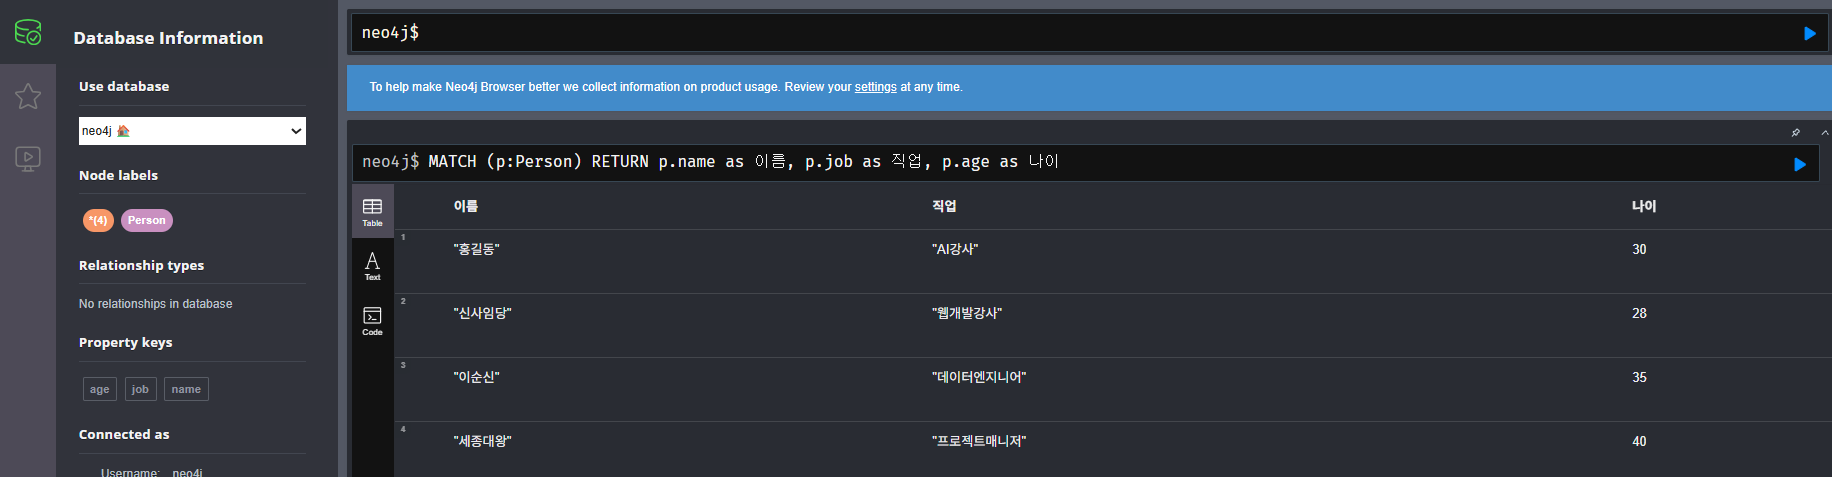

### 예제 4: 특정 속성으로 노드 조회

변수를 사용하여 노드를 참조하고 특정 속성으로 조회할 수 있습니다.


In [8]:
# ============================================
# Cypher 쿼리 작성
# ============================================
# MATCH (p:Person {name: '홍길동'}): 
#   - Person 레이블을 가진 노드 중에서
#   - name 속성이 '홍길동'인 노드만 찾기
#   - {name: '홍길동'}: 속성 필터 조건
# RETURN p: 찾은 노드 전체를 반환
query = """
MATCH (p:Person {name: '홍길동'})
RETURN p
"""

# ============================================
# 쿼리 실행
# ============================================
result = run_query(query)

# ============================================
# 결과 처리 및 출력
# ============================================
# record['p']: 쿼리에서 반환한 노드 객체
# dict(node): 노드 객체를 딕셔너리로 변환하여 모든 속성을 확인
for record in result:
    node = record['p']  # 노드 객체 가져오기
    print(f"노드 속성: {dict(node)}")
    
    # 개별 속성 접근 예시
    if 'name' in node:
        print(f"  - 이름: {node['name']}")
    if 'job' in node:
        print(f"  - 직업: {node['job']}")
    if 'age' in node:
        print(f"  - 나이: {node['age']}")


노드 속성: {'name': '홍길동', 'job': 'AI강사', 'age': 30}
  - 이름: 홍길동
  - 직업: AI강사
  - 나이: 30


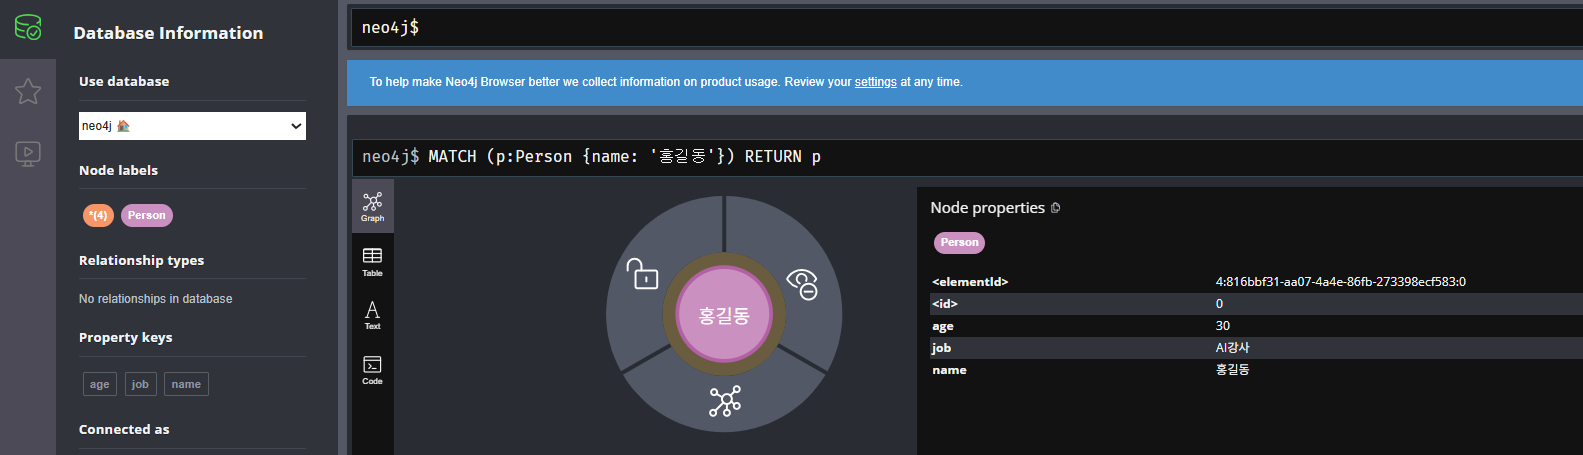

## 4. 관계 생성과 조회

### 4.1 관계 생성

두 노드 사이에 관계를 생성합니다. 관계는 방향성을 가집니다.


In [9]:
# ============================================
# Cypher 쿼리 작성
# ============================================
# 1단계: MATCH로 관계를 생성할 두 노드를 찾기
#   - (a:Person {name: '홍길동'}): 홍길동 노드를 변수 a에 할당
#   - (b:Person {name: '신사임당'}): 신사임당 노드를 변수 b에 할당
#   - 쉼표(,)로 구분하여 여러 노드를 한 번에 찾을 수 있음
# 2단계: CREATE로 관계 생성
#   - (a)-[:MARRIED_TO {since: 2020}]->(b)
#     - (a): 시작 노드 (홍길동)
#     - -[:MARRIED_TO]->: 관계 타입과 방향
#       - [:MARRIED_TO]: 관계 타입 (결혼 관계)
#       - {since: 2020}: 관계의 속성 (2020년부터)
#       - ->: 방향 (a에서 b로)
#     - (b): 끝 노드 (신사임당)
query = """
MATCH (a:Person {name: '홍길동'}), (b:Person {name: '신사임당'})
CREATE (a)-[:MARRIED_TO {since: 2020}]->(b)
RETURN a.name, b.name
"""

# ============================================
# 쿼리 실행
# ============================================
result = run_query(query)

# ============================================
# 결과 처리 및 출력
# ============================================
# record['a.name']: 쿼리에서 반환한 a 노드의 name 속성
for record in result:
    print(f"{record['a.name']}와 {record['b.name']}가 결혼 관계로 연결되었습니다!")
    print(f"관계 속성: 2020년부터 결혼 관계")


홍길동와 신사임당가 결혼 관계로 연결되었습니다!
관계 속성: 2020년부터 결혼 관계


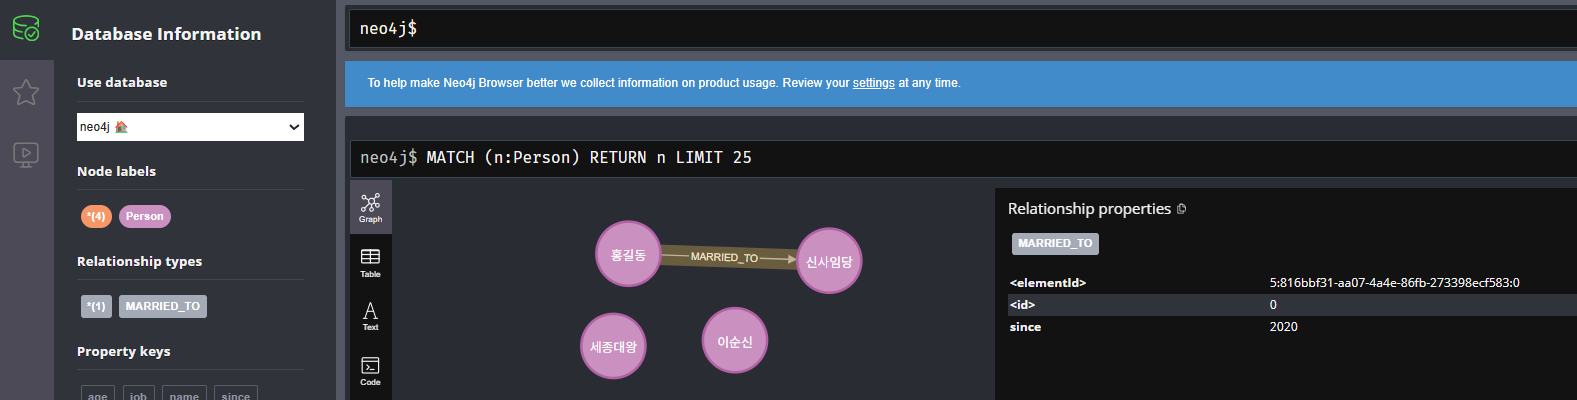

### 예제 5: 여러 관계 생성

다양한 관계 타입을 생성해봅시다.


In [10]:
# ============================================
# Cypher 쿼리 작성
# ============================================
# 1단계: MATCH로 여러 노드를 한 번에 찾기
#   - 각 노드에 의미있는 변수명 부여 (hong, shin, lee, sejong)
# 2단계: CREATE로 여러 관계를 한 번에 생성
#   - (hong)-[:KNOWS {since: 2018}]->(lee): 홍길동이 2018년부터 이순신을 알고 있음
#   - (hong)-[:KNOWS {since: 2019}]->(sejong): 홍길동이 2019년부터 세종대왕을 알고 있음
#   - (shin)-[:KNOWS {since: 2020}]->(lee): 신사임당이 2020년부터 이순신을 알고 있음
#   - (lee)-[:WORKS_WITH]->(sejong): 이순신이 세종대왕과 함께 일함 (속성 없음)
query = """
MATCH 
    (hong:Person {name: '홍길동'}),
    (shin:Person {name: '신사임당'}),
    (lee:Person {name: '이순신'}),
    (sejong:Person {name: '세종대왕'})
CREATE 
    (hong)-[:KNOWS {since: 2018}]->(lee),
    (hong)-[:KNOWS {since: 2019}]->(sejong),
    (shin)-[:KNOWS {since: 2020}]->(lee),
    (lee)-[:WORKS_WITH]->(sejong)
RETURN '관계 생성 완료!' as result
"""

# ============================================
# 쿼리 실행
# ============================================
result = run_query(query)

# ============================================
# 결과 확인
# ============================================
print(result[0]['result'])
print("팁: 여러 관계를 한 번에 생성하면 트랜잭션이 효율적으로 처리됩니다.")


관계 생성 완료!
팁: 여러 관계를 한 번에 생성하면 트랜잭션이 효율적으로 처리됩니다.


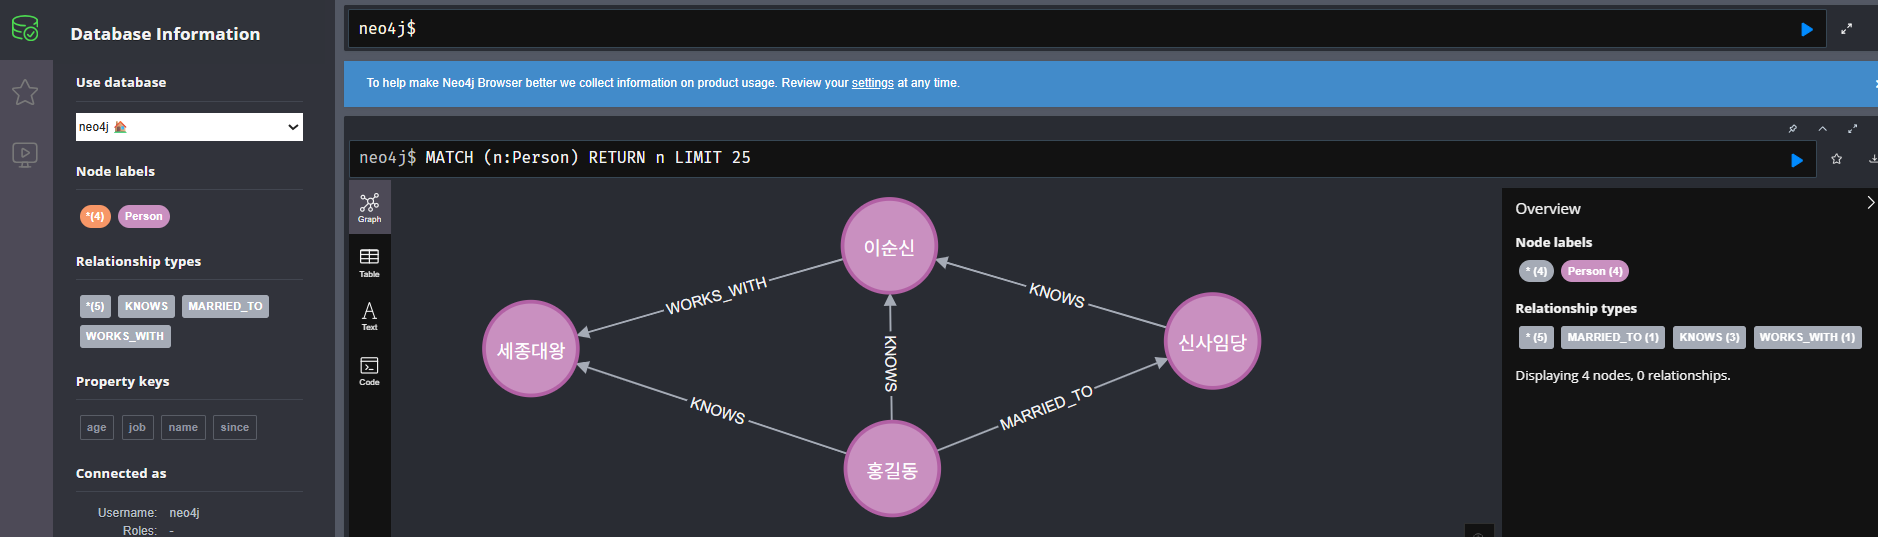

### 예제 6: 관계 기반 조회

관계를 통해 연결된 노드들을 찾아봅시다.


In [11]:
# ============================================
# Cypher 쿼리 작성
# ============================================
# MATCH (a:Person)-[:MARRIED_TO]->(b:Person):
#   - Person 노드 a와 Person 노드 b 사이에
#   - MARRIED_TO 관계가 있는 패턴을 찾기
#   - -[:MARRIED_TO]->: 관계 타입과 방향 지정
#     - -: 관계 시작
#     - [:MARRIED_TO]: 관계 타입
#     - ->: a에서 b로의 방향
query = """
MATCH (a:Person)-[:MARRIED_TO]->(b:Person)
RETURN a.name as 배우자1, b.name as 배우자2
"""

# ============================================
# 쿼리 실행
# ============================================
result = run_query(query)

# ============================================
# 결과 처리 및 출력
# ============================================
if result:
    print("결혼 관계로 연결된 사람들:")
    for record in result:
        print(f"{record['배우자1']} ↔ {record['배우자2']}")
else:
    print("결혼 관계가 없습니다.")


결혼 관계로 연결된 사람들:
홍길동 ↔ 신사임당


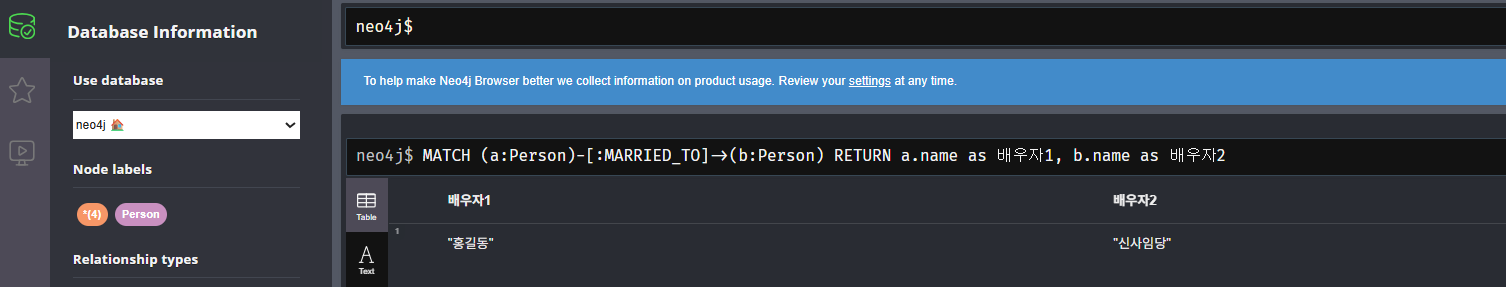

### 예제 7: 특정 사람이 아는 사람들 찾기

홍길동이 아는 모든 사람을 찾아봅시다.


In [12]:
# ============================================
# Cypher 쿼리 작성
# ============================================
# MATCH (hong:Person {name: '홍길동'})-[:KNOWS]->(friend:Person):
#   - 홍길동 노드에서 시작하여
#   - KNOWS 관계를 따라
#   - 연결된 Person 노드들을 찾기
#   - friend: 연결된 노드를 참조하는 변수
query = """
MATCH (hong:Person {name: '홍길동'})-[:KNOWS]->(friend:Person)
RETURN friend.name as 이름, friend.job as 직업
"""

# ============================================
# 쿼리 실행
# ============================================
result = run_query(query)

# ============================================
# 결과 처리 및 출력
# ============================================
if result:
    print("홍길동이 아는 사람들:")
    for record in result:
        print(f"  - {record['이름']} ({record['직업']})")
else:
    print("아는 사람이 없습니다.")
    
print(f"\n총 {len(result)}명을 알고 있습니다.")


홍길동이 아는 사람들:
  - 이순신 (데이터엔지니어)
  - 세종대왕 (프로젝트매니저)

총 2명을 알고 있습니다.


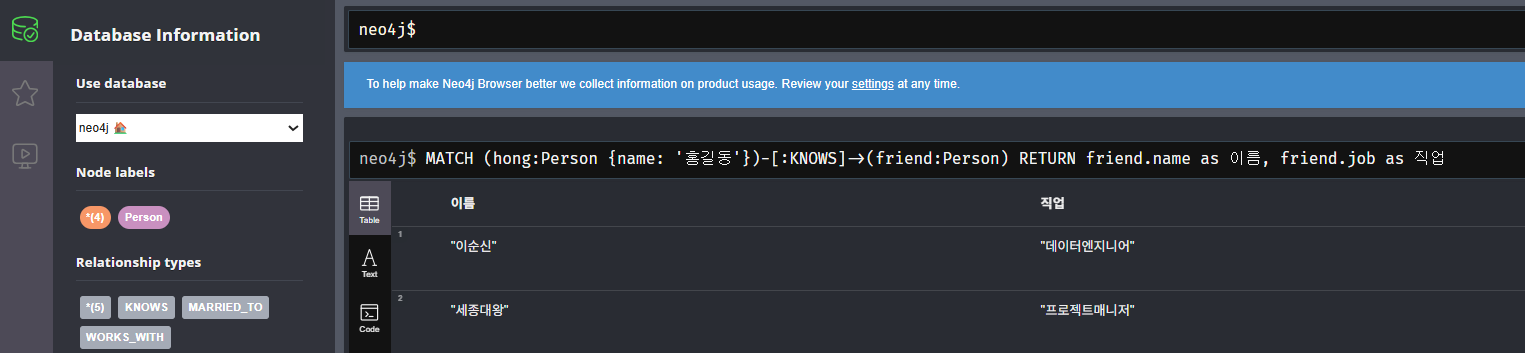

## 5. 조건 검색 (WHERE)

WHERE 절을 사용하여 조건에 맞는 노드나 관계를 필터링할 수 있습니다.


In [13]:
# ============================================
# Cypher 쿼리 작성
# ============================================
# MATCH (p:Person): 모든 Person 노드를 찾기
# WHERE p.age >= 30: 나이가 30 이상인 노드만 필터링
#   - p.age: 노드의 age 속성 접근
#   - >=: 비교 연산자 (이상)
# RETURN: 결과로 반환할 데이터
# ORDER BY p.age DESC: 나이를 내림차순으로 정렬
#   - DESC: 내림차순 (큰 값부터)
#   - ASC: 오름차순 (작은 값부터, 기본값)
query = """
MATCH (p:Person)
WHERE p.age >= 30
RETURN p.name as 이름, p.age as 나이
ORDER BY p.age DESC
"""

# ============================================
# 쿼리 실행
# ============================================
result = run_query(query)

# ============================================
# 결과 처리 및 출력
# ============================================
print("30세 이상인 사람들:")
for record in result:
    print(f"  - {record['이름']}: {record['나이']}세")
    
print(f"\n총 {len(result)}명이 30세 이상입니다.")


30세 이상인 사람들:
  - 세종대왕: 40세
  - 이순신: 35세
  - 홍길동: 30세

총 3명이 30세 이상입니다.


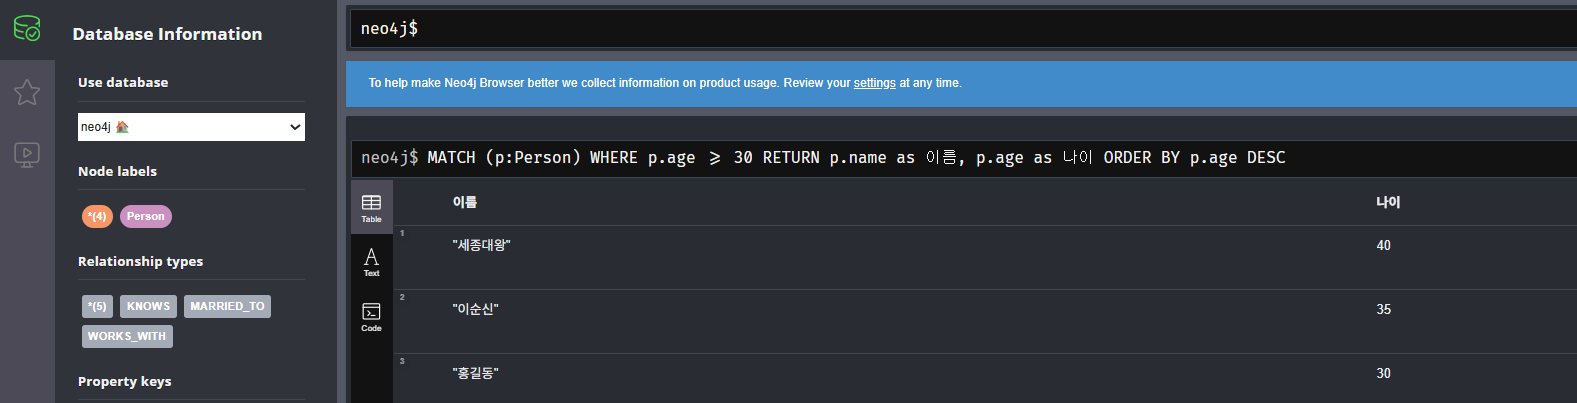

### 예제 8: 복합 조건 검색

여러 조건을 조합하여 검색할 수 있습니다.


In [14]:
# ============================================
# Cypher 쿼리 작성
# ============================================
# WHERE 절에서 여러 조건을 조합:
#   - p.age >= 25: 나이가 25 이상
#   - AND: 논리 연산자 (둘 다 만족해야 함)
#   - p.job CONTAINS '강사': 직업에 '강사'가 포함됨
#     - CONTAINS: 문자열 포함 여부 확인 (대소문자 구분)
#     - 다른 문자열 함수: STARTS WITH, ENDS WITH, =~ (정규식)
query = """
MATCH (p:Person)
WHERE p.age >= 25 AND p.job CONTAINS '강사'
RETURN p.name as 이름, p.job as 직업, p.age as 나이
"""

# ============================================
# 쿼리 실행
# ============================================
result = run_query(query)

# ============================================
# 결과 처리 및 출력
# ============================================
print("조건에 맞는 사람들:")
print("  (나이 25세 이상 AND 직업에 '강사' 포함)")
for record in result:
    print(f"  - {record['이름']}: {record['직업']} ({record['나이']}세)")
    
print(f"\n총 {len(result)}명이 조건에 맞습니다.")


조건에 맞는 사람들:
  (나이 25세 이상 AND 직업에 '강사' 포함)
  - 홍길동: AI강사 (30세)
  - 신사임당: 웹개발강사 (28세)

총 2명이 조건에 맞습니다.


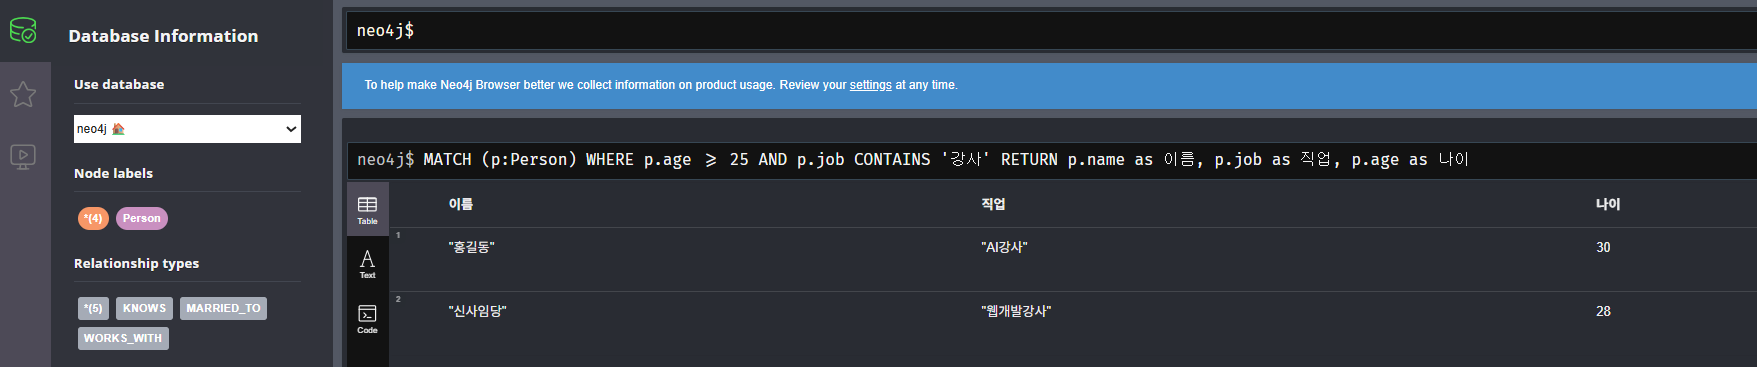

## 6. 경로 탐색

그래프의 강력한 기능 중 하나는 경로 탐색입니다. 여러 단계의 관계를 따라 탐색할 수 있습니다.


### 예제 9: 1단계 경로 탐색

직접 연결된 노드들을 찾습니다.


In [15]:
# ============================================
# Cypher 쿼리 작성
# ============================================
# MATCH (hong:Person {name: '홍길동'})-[*1]-(connected:Person):
#   - [*1]: 정확히 1단계 관계 (직접 연결)
#     - *: 가변 길이 관계 패턴
#     - 1: 정확히 1단계
#   - -: 양방향 관계 (방향 무시)
#     - ->: 한 방향만
#     - <-: 반대 방향만
#   - DISTINCT: 중복 제거 (같은 노드가 여러 번 나타날 수 있으므로)
query = """
MATCH (hong:Person {name: '홍길동'})-[*1]-(connected:Person)
RETURN DISTINCT connected.name as 이름
"""

# ============================================
# 쿼리 실행
# ============================================
result = run_query(query)

# ============================================
# 결과 처리 및 출력
# ============================================
print("홍길동과 직접 연결된 사람들 (1단계):")
for record in result:
    print(f"  - {record['이름']}")
    
print(f"\n총 {len(result)}명과 직접 연결되어 있습니다.")


홍길동과 직접 연결된 사람들 (1단계):
  - 신사임당
  - 이순신
  - 세종대왕

총 3명과 직접 연결되어 있습니다.


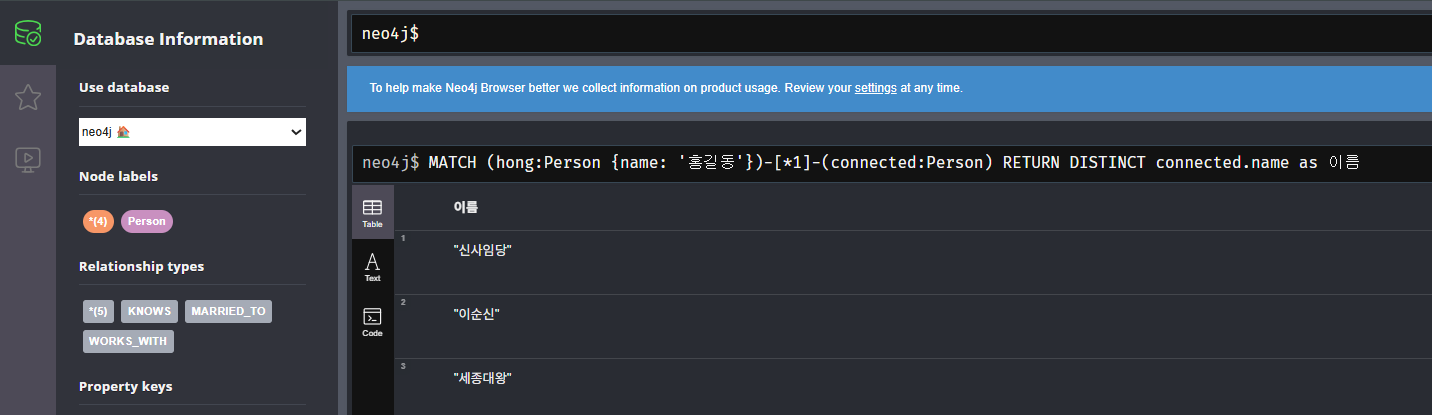

### 예제 10: 다단계 경로 탐색

1단계부터 3단계까지의 경로를 탐색합니다.


In [17]:
# ============================================
# Cypher 쿼리 작성
# ============================================
# MATCH path = (start:Person {name: '홍길동'})-[*1..3]-(end:Person):
#   - path = : 경로 전체를 path 변수에 저장
#   - [*1..3]: 1단계부터 3단계까지의 관계
#     - [*1..3]: 1~3단계
#     - [*2..5]: 2~5단계
#     - [*]: 모든 단계 (제한 없음, 주의해서 사용!)
#   - WHERE start <> end: 시작 노드와 끝 노드가 다르도록 필터링
#   - LIMIT 10: 결과를 10개로 제한 (성능 및 출력 제어)
query = """
MATCH path = (start:Person {name: '홍길동'})-[*1..3]-(end:Person)
WHERE start <> end
RETURN path
LIMIT 10
"""

# ============================================
# 쿼리 실행
# ============================================
result = run_query(query)

# ============================================
# 결과 처리 및 출력
# ============================================
print(f"총 {len(result)}개의 경로를 찾았습니다.")
print("\n경로 예시:")
# path.nodes: 경로에 포함된 모든 노드들
# path.relationships: 경로에 포함된 모든 관계들
for i, record in enumerate(result, 1):
    path = record['path']
    # 경로의 각 노드에서 name 속성을 추출
    nodes = [node['name'] for node in path.nodes if 'name' in node]
    print(f"  {i}. {' -> '.join(nodes)}")
    
print("\n팁: 경로 탐색은 네트워크 분석, 추천 시스템 등에 활용됩니다.")


총 9개의 경로를 찾았습니다.

경로 예시:
  1. 홍길동 -> 신사임당
  2. 홍길동 -> 신사임당 -> 이순신
  3. 홍길동 -> 신사임당 -> 이순신 -> 세종대왕
  4. 홍길동 -> 이순신
  5. 홍길동 -> 이순신 -> 신사임당
  6. 홍길동 -> 이순신 -> 세종대왕
  7. 홍길동 -> 세종대왕
  8. 홍길동 -> 세종대왕 -> 이순신
  9. 홍길동 -> 세종대왕 -> 이순신 -> 신사임당

팁: 경로 탐색은 네트워크 분석, 추천 시스템 등에 활용됩니다.


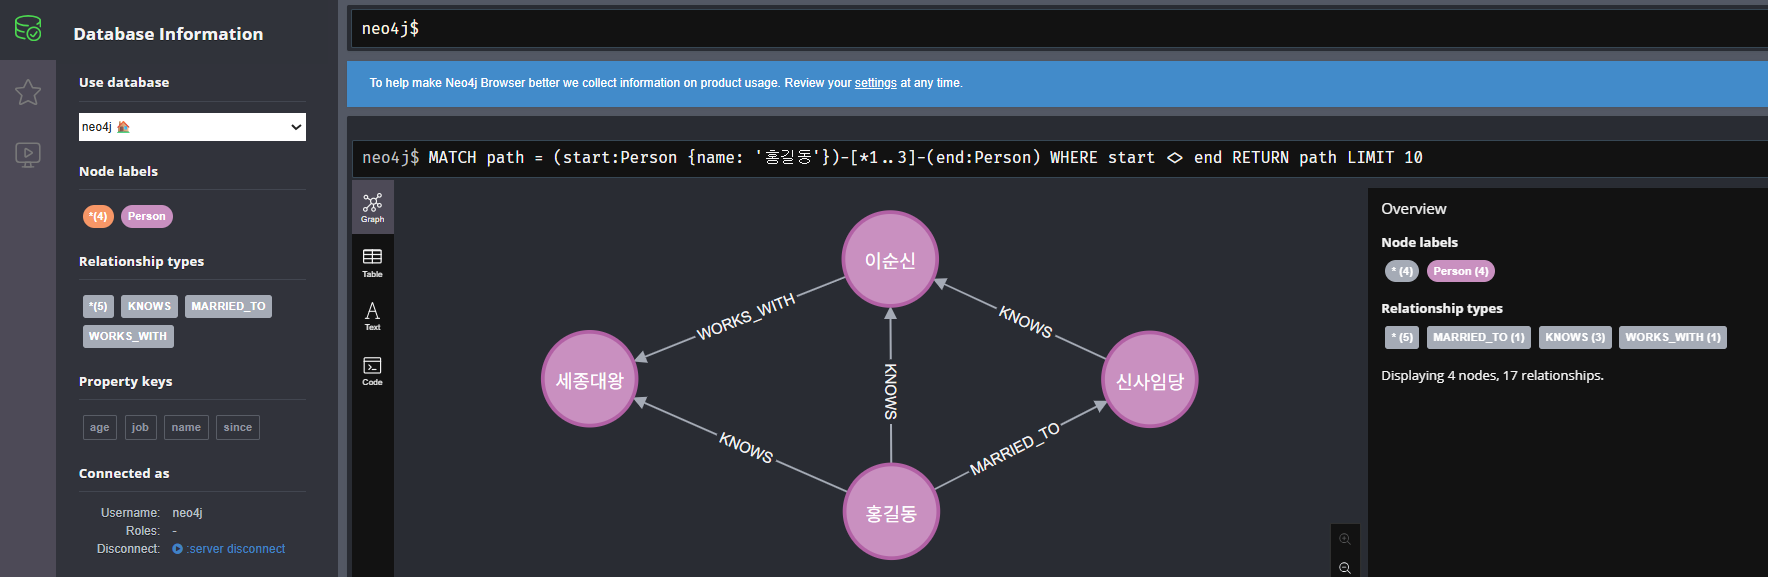

### 예제 11: 최단 경로 찾기

두 노드 사이의 최단 경로를 찾습니다.


In [18]:
# ============================================
# Cypher 쿼리 작성
# ============================================
# shortestPath(): 두 노드 사이의 최단 경로를 찾는 함수
#   - (start:Person {name: '홍길동'}): 시작 노드
#   - [*]: 모든 관계 타입, 모든 단계 (제한 없음)
#   - (end:Person {name: '세종대왕'}): 끝 노드
# length(path): 경로의 길이 (관계의 개수)
query = """
MATCH path = shortestPath(
    (start:Person {name: '홍길동'})-[*]-(end:Person {name: '세종대왕'})
)
RETURN path, length(path) as 경로길이
"""

# ============================================
# 쿼리 실행
# ============================================
result = run_query(query)

# ============================================
# 결과 처리 및 출력
# ============================================
if result:
    path = result[0]['path']  # 첫 번째 결과의 경로
    length = result[0]['경로길이']  # 경로 길이
    
    # 경로의 모든 노드 이름 추출
    nodes = [node['name'] for node in path.nodes if 'name' in node]
    
    print(f"최단 경로 (길이: {length}):")
    print(" -> ".join(nodes))
    
    print(f"\n경로 길이 {length}는 관계의 개수를 의미합니다.")
    print("   (노드 개수 - 1 = 관계 개수)")
else:
    print("경로를 찾을 수 없습니다.")
    print("두 노드가 연결되어 있지 않거나, 관계가 없는 경우입니다.")


최단 경로 (길이: 1):
홍길동 -> 세종대왕

경로 길이 1는 관계의 개수를 의미합니다.
   (노드 개수 - 1 = 관계 개수)


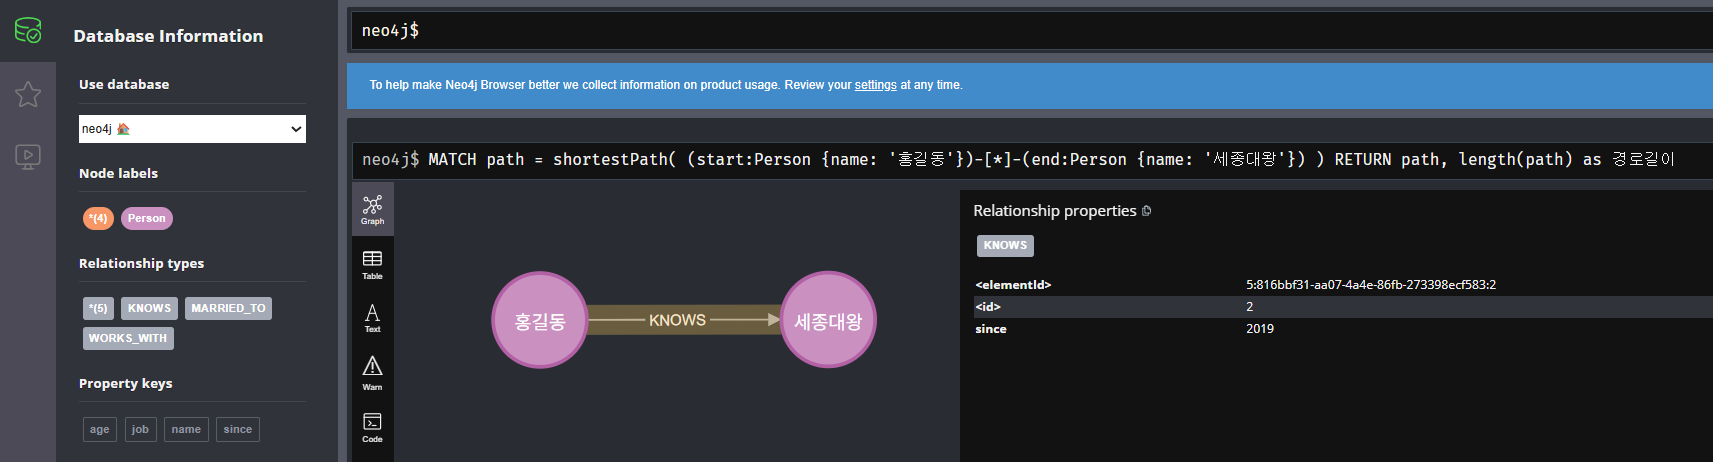

## 7. 데이터 수정 및 삭제

### 7.1 속성 수정 (SET)

기존 노드의 속성을 수정할 수 있습니다.


In [19]:
# ============================================
# Cypher 쿼리 작성
# ============================================
# 1단계: MATCH로 수정할 노드 찾기
# 2단계: SET으로 속성 수정
#   - SET p.age = 31: age 속성을 31로 변경
#   - 여러 속성을 한 번에 수정: SET p.age = 31, p.job = '새직업'
# 3단계: RETURN으로 수정된 결과 확인
query = """
MATCH (p:Person {name: '홍길동'})
SET p.age = 31
RETURN p.name as 이름, p.age as 나이
"""

# ============================================
# 쿼리 실행
# ============================================
result = run_query(query)

# ============================================
# 결과 처리 및 출력
# ============================================
for record in result:
    print(f"{record['이름']}의 나이가 {record['나이']}세로 업데이트되었습니다.")
    
print("\nSET은 기존 속성을 수정하거나, 없는 속성을 추가할 수 있습니다.")


홍길동의 나이가 31세로 업데이트되었습니다.

SET은 기존 속성을 수정하거나, 없는 속성을 추가할 수 있습니다.


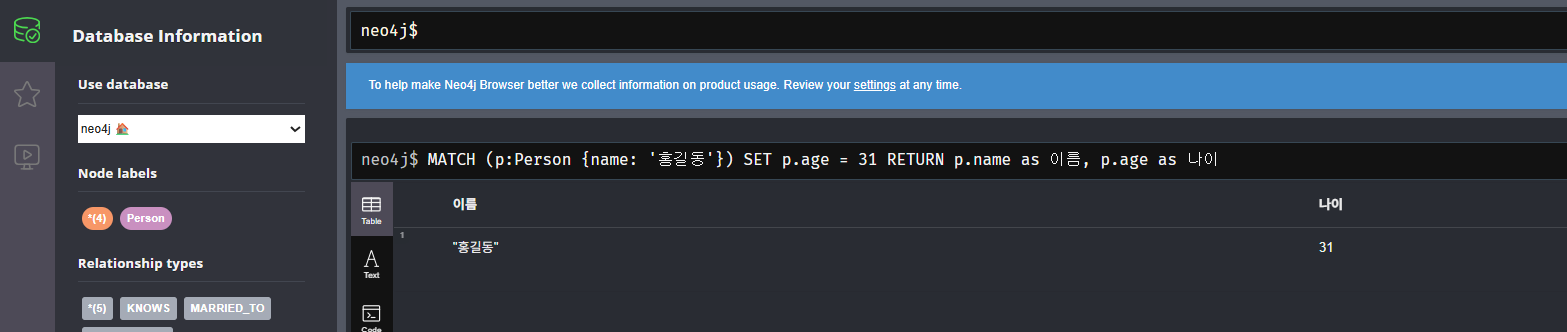

### 7.2 속성 추가

새로운 속성을 추가할 수 있습니다.


In [20]:
# ============================================
# Cypher 쿼리 작성
# ============================================
# SET p.email = 'hong@example.com':
#   - email 속성이 있으면 수정, 없으면 추가
#   - Neo4j는 스키마가 없으므로 자유롭게 속성 추가 가능
query = """
MATCH (p:Person {name: '홍길동'})
SET p.email = 'hong@example.com'
RETURN p.name as 이름, p.email as 이메일
"""

# ============================================
# 쿼리 실행
# ============================================
result = run_query(query)

# ============================================
# 결과 처리 및 출력
# ============================================
for record in result:
    print(f"{record['이름']}의 이메일: {record['이메일']}")
    
print("\nNeo4j는 스키마가 없어서 각 노드마다 다른 속성을 가질 수 있습니다.")


홍길동의 이메일: hong@example.com

Neo4j는 스키마가 없어서 각 노드마다 다른 속성을 가질 수 있습니다.


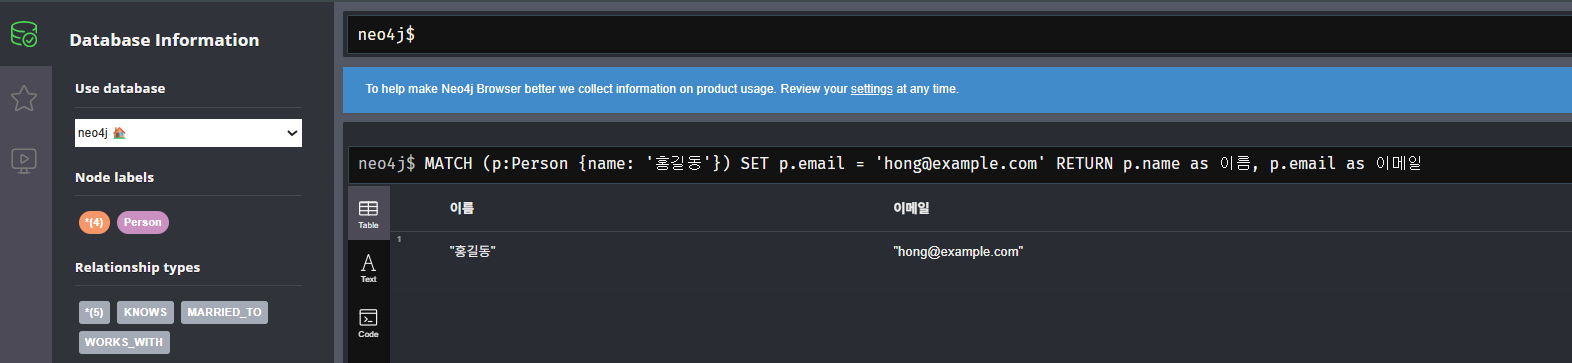

### 7.3 MERGE 사용하기

MERGE는 "있으면 유지, 없으면 생성"하는 UPSERT 연산입니다. 중복 생성을 방지할 때 유용합니다.


In [21]:
# ============================================
# Cypher 쿼리 작성
# ============================================
# MERGE (p:Person {name: '김철수'}):
#   - name이 '김철수'인 Person 노드가 있으면 찾기
#   - 없으면 새로 생성
# ON CREATE SET: 노드를 생성할 때만 실행
#   - p.created = timestamp(): 생성 시간 기록
# ON MATCH SET: 노드를 찾았을 때만 실행
#   - p.lastSeen = timestamp(): 최근 접속 시간 업데이트
# timestamp(): 현재 시간을 밀리초로 반환하는 함수
query = """
MERGE (p:Person {name: '김철수'})
ON CREATE SET p.created = timestamp()
ON MATCH SET p.lastSeen = timestamp()
RETURN p.name as 이름, p.created as 생성시간, p.lastSeen as 최근접속
"""

# ============================================
# 쿼리 실행
# ============================================
result = run_query(query)

# ============================================
# 결과 처리 및 출력
# ============================================
for record in result:
    print(f"이름: {record['이름']}")
    if record['생성시간']:
        # timestamp()는 밀리초 단위이므로 읽기 쉽게 변환 가능
        print(f"  생성 시간: {record['생성시간']} (밀리초)")
    if record['최근접속']:
        print(f"  최근 접속: {record['최근접속']} (밀리초)")
        
print("\nMERGE는 중복 데이터를 방지하는 데 매우 유용합니다.")
print("   같은 쿼리를 여러 번 실행해도 노드는 하나만 생성됩니다.")


이름: 김철수
  생성 시간: 1764212861537 (밀리초)

MERGE는 중복 데이터를 방지하는 데 매우 유용합니다.
   같은 쿼리를 여러 번 실행해도 노드는 하나만 생성됩니다.


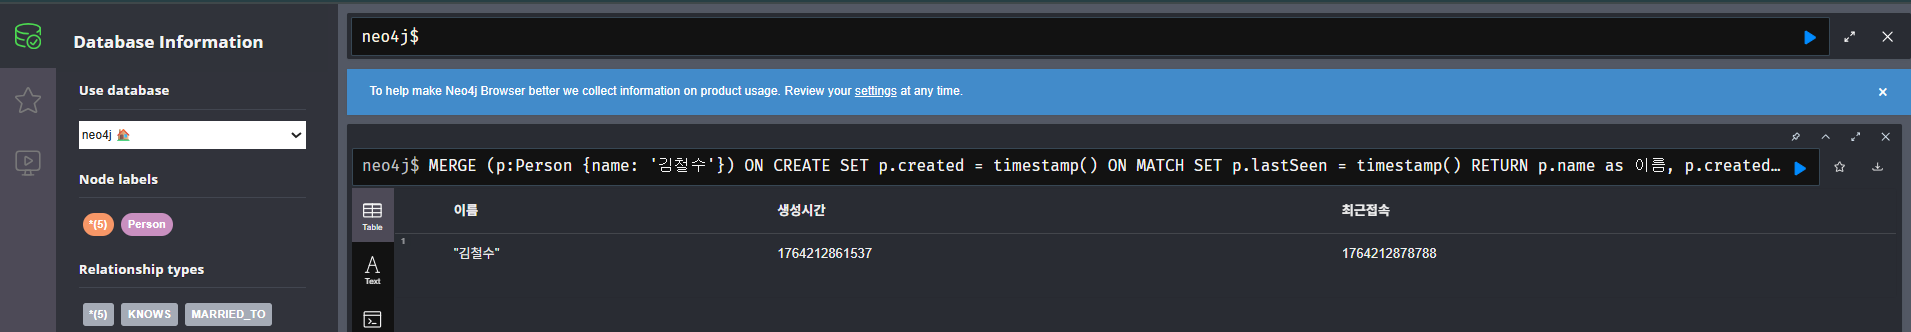

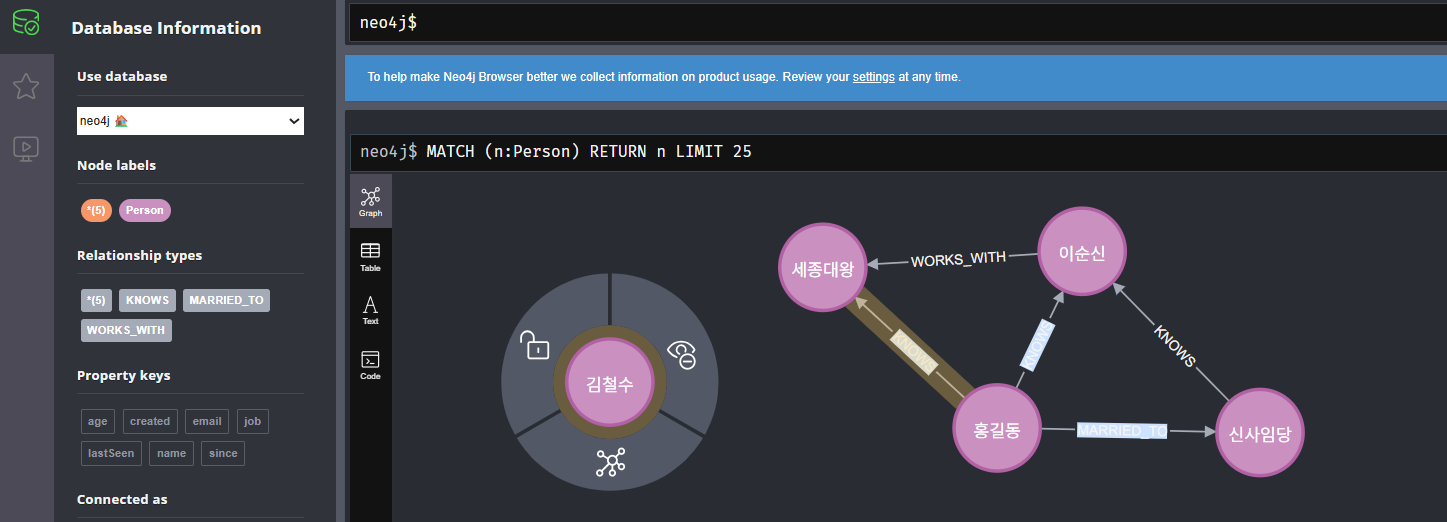

### 7.4 노드 삭제

노드를 삭제할 수 있습니다. 관계가 있는 경우 `DETACH DELETE`를 사용해야 합니다.


In [23]:
# 노드 삭제 (관계도 함께 삭제)

query = """
MATCH (p:Person {name: '김철수'})
DETACH DELETE p
RETURN '삭제 완료' as result
"""

result = run_query(query)
print("노드가 삭제되었습니다.")


노드가 삭제되었습니다.


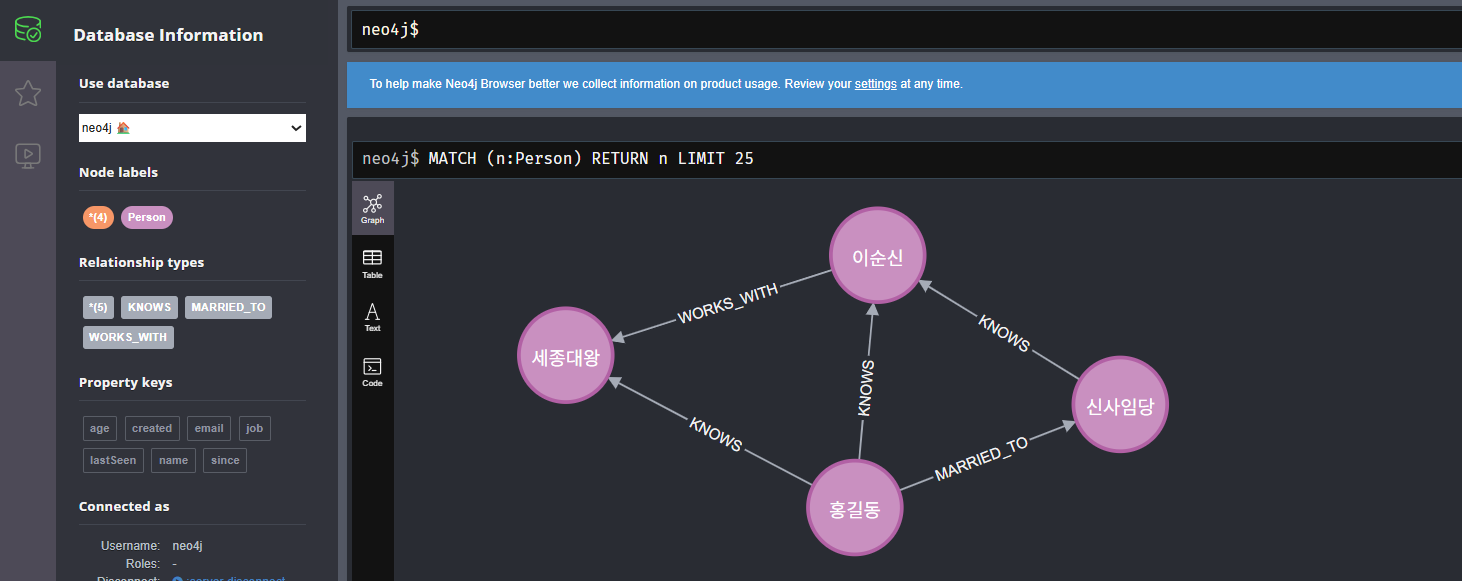

### 7.5 모든 데이터 삭제

모든 노드와 관계를 삭제하고 싶을 때 사용합니다.


In [24]:
# 모든 데이터 삭제
# 주의: 모든 데이터가 삭제됩니다!

query = """
MATCH (n)
DETACH DELETE n
"""

result = run_query(query)
print("모든 데이터가 삭제되었습니다.")


모든 데이터가 삭제되었습니다.


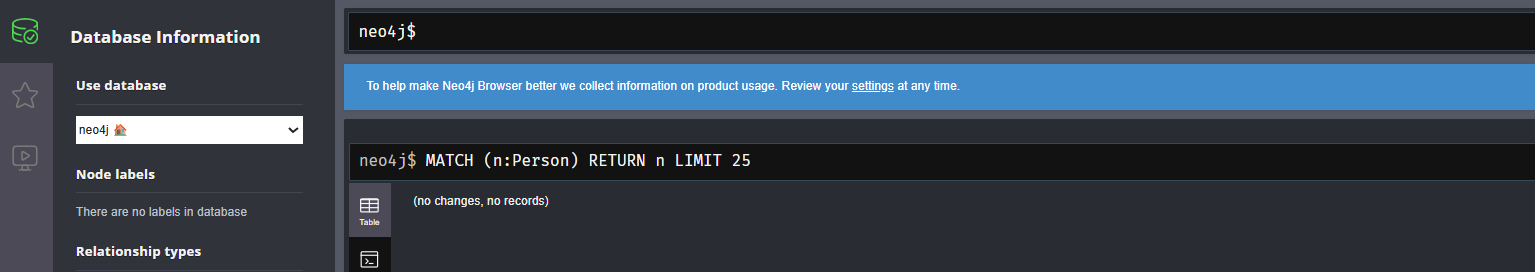

## 추가 학습 자료


### 유용한 Cypher 함수들

| 함수 | 설명 | 예시 |
|------|------|------|
| `COUNT()` | 개수 집계 | `RETURN COUNT(p)` |
| `AVG()` | 평균 계산 | `RETURN AVG(p.age)` |
| `SUM()` | 합계 계산 | `RETURN SUM(p.age)` |
| `MAX()` / `MIN()` | 최대/최소값 | `RETURN MAX(p.age)` |
| `COLLECT()` | 리스트로 수집 | `RETURN COLLECT(p.name)` |
| `DISTINCT` | 중복 제거 | `RETURN DISTINCT p.job` |
| `ORDER BY` | 정렬 | `ORDER BY p.age DESC` |
| `LIMIT` | 결과 제한 | `LIMIT 10` |



### 고급 패턴

1. **옵셔널 매칭**: `OPTIONAL MATCH` - 일치하는 것이 없어도 결과에 포함
2. **집계 함수**: `WITH` 절을 사용하여 중간 결과 처리
3. **리스트 이해**: `[x IN list WHERE condition]`
4. **CASE 문**: 조건부 로직 처리



### 참고 자료
- [Neo4j 공식 문서](https://neo4j.com/docs/)
- [Cypher 쿼리 언어 가이드](https://neo4j.com/docs/cypher-manual/current/)
- [Cypher Cheat Sheet](https://neo4j.com/docs/cypher-cheat-sheet/)
